# QUESTÃO 8: Sistema de Recomendação de Produtos

## Seção 0: Imports e Configuração

In [9]:
"""
Imports e Configuração do Notebook
==================================
Carrega dependências para análise e sistema de recomendação.
"""

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Configuração de diretórios (ROBUSTO para Jupyter)
notebook_dir = Path.cwd()
ROOT_DIR = None

# Procurar "Desafio-Lighthouse-Dados-AI" na hierarquia
for possible_root in [notebook_dir] + list(notebook_dir.parents):
    if possible_root.name == "Desafio-Lighthouse-Dados-AI":
        ROOT_DIR = possible_root
        break

# Fallback: se não encontrou, assumir 2 níveis acima
if ROOT_DIR is None:
    ROOT_DIR = notebook_dir.parent.parent

SRC_DIR = ROOT_DIR / "src"
DATA_PROCESSED = ROOT_DIR / "data" / "processed"

print(f"📁 Diretório: {ROOT_DIR}")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Importações
print("⏳ Carregando bibliotecas...", end=" ")
import pandas as pd
import numpy as np
print("pandas numpy", end=" ")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
print("sklearn")

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:.2f}".format)

print("⏳ Carregando módulos personalizados...", end=" ")
try:
    from data.load_data import load_vendas, load_produtos, load_clientes
    from models.recommendation import (construir_matriz_usuario_item, 
                                       calcular_similaridade_produtos, 
                                       top_k_similares)
    from utils import salvar_csv, garantir_pasta
    
    print("Todos os módulos carregados com sucesso!")
except ImportError as e:
    print(f"\n✗ Erro ao importar módulos: {e}")
    raise

📁 Diretório: c:\Projetos\Desafio-Lighthouse-Dados-AI
⏳ Carregando bibliotecas... pandas numpy sklearn
⏳ Carregando módulos personalizados... Todos os módulos carregados com sucesso!


## Seção 1: Carregamento e Preparação

In [10]:
"""
Carregamento de Dados
====================
"""

print("Carregando dados...\n")

# Carregar dados
df_vendas = load_vendas()
df_produtos = load_produtos()

try:
    df_clientes = load_clientes()
except:
    print("⚠️  Arquivo de clientes não disponível. Usando ID de clientes das vendas.")
    df_clientes = None

print(f"Vendas: {df_vendas.shape[0]} registros")
print(f"Produtos: {df_produtos.shape[0]} produtos")
if df_clientes is not None:
    print(f"Clientes: {df_clientes.shape[0]} registros")

# Detectar nomes de colunas corretos
col_cliente = 'id_client' if 'id_client' in df_vendas.columns else 'id_cliente'
col_produto = 'id_product' if 'id_product' in df_vendas.columns else 'id_produto'
col_produto_info = 'code' if 'code' in df_produtos.columns else 'id'

print(f"\nClientes únicos nas vendas: {df_vendas[col_cliente].nunique()}")
print(f"Produtos únicos nas vendas: {df_vendas[col_produto].nunique()}")

# Resumo de dados
print(f"\nExemplos de dados:")
print(f"\nPrimeiros produtos:")
cols_produtos = ['code' if 'code' in df_produtos.columns else 'id',
                 'name' if 'name' in df_produtos.columns else 'nome',
                 'actual_category' if 'actual_category' in df_produtos.columns else 'categoria',
                 'price' if 'price' in df_produtos.columns else 'preco']
cols_produtos = [c for c in cols_produtos if c in df_produtos.columns]
display(df_produtos[cols_produtos].head(5))

print(f"\nExemplos de vendas:")
cols_vendas = [col_cliente, col_produto, 'sale_date' if 'sale_date' in df_vendas.columns else 'data', 'total']
cols_vendas = [c for c in cols_vendas if c in df_vendas.columns]
display(df_vendas[cols_vendas].head(5))

Carregando dados...

Colunas encontradas em vendas: ['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date']
Coluna de data detectada: 'sale_date'
Coluna de total detectada: 'total'
Shape final de vendas: (9895, 6)
Colunas encontradas em produtos: ['name', 'price', 'code', 'actual_category']
Shape de produtos: (157, 4)
Colunas encontradas em clientes: ['full_name', 'location', 'code', 'email']
Shape de clientes: (49, 4)
Vendas: 9895 registros
Produtos: 157 produtos
Clientes: 49 registros

Clientes únicos nas vendas: 49
Produtos únicos nas vendas: 150

Exemplos de dados:

Primeiros produtos:


,code,name,actual_category,price
0,1,Transponder AIS Maré Magnum,ELETRONICOS,R$ 33122.52
1,2,Transponder Furuno Marlin,ELETRONICOS,R$ 13998.15
2,3,Radar Furuno Pulse Leviathan,E L E T R Ô N I C O S,R$ 9024.19
3,4,Rádio AIS Hydro Tidal Zen,Eletrunicos,R$ 3381.88
4,5,Piloto Automático Furuno Storm,Eletronicoz,R$ 23669.01



Exemplos de vendas:


,id_client,id_product,data,total
0,42,105,2023-09-10,3405.00
1,3,136,2024-09-15,16873.90
2,25,139,2024-08-13,9475.30
3,20,23,2023-02-03,55893.00
4,8,57,2024-02-12,451403.90


---

# QUESTÃO 8 - SISTEMA DE RECOMENDAÇÃO

## Objetivo
- Construir matriz Usuário-Item (cliente × produto)
- Calcular similaridade de produtos (Cosine Similarity)
- Gerar recomendações top-K
- Validar e visualizar resultados

## Construção da Matriz Usuário-Item

In [11]:
"""
Questão 8: Sistema de Recomendação
===================================
"""

print("="*60)
print("QUESTÃO 8 - SISTEMA DE RECOMENDAÇÃO DE PRODUTOS")
print("="*60 + "\n")

# Construir matriz usuário-item
matriz_usuario_item = construir_matriz_usuario_item(df_vendas)

print(f"\nMATRIZ USUÁRIO-ITEM:")
print(f"  Dimensões: {matriz_usuario_item.shape[0]} clientes × {matriz_usuario_item.shape[1]} produtos")
print(f"  Tipos de transações: Binary (comprou/não comprou)")
print(f"  Sparsidade: {(1 - matriz_usuario_item.astype(bool).sum().sum() / (matriz_usuario_item.shape[0] * matriz_usuario_item.shape[1])) * 100:.2f}%")
print(f"  Número de transações (não-zero): {matriz_usuario_item.astype(bool).sum().sum()}")

print(f"\nExemplo da matriz (primeiros 5 clientes × 8 produtos):")
display(matriz_usuario_item.iloc[:5, :8])

QUESTÃO 8 - SISTEMA DE RECOMENDAÇÃO DE PRODUTOS


MATRIZ USUÁRIO-ITEM:
  Dimensões: 49 clientes × 150 produtos
  Tipos de transações: Binary (comprou/não comprou)
  Sparsidade: 26.35%
  Número de transações (não-zero): 5413

Exemplo da matriz (primeiros 5 clientes × 8 produtos):


id_product,1,2,3,4,5,6,7,8
id_client,,,,,,,,
1,1,0,1,1,1,1,0,0
2,0,1,1,0,1,1,1,1
3,1,1,1,1,1,1,1,0
4,1,1,0,1,1,0,1,0
5,1,1,0,1,1,1,1,1


In [12]:
"""
Cálculo de Similaridade de Produtos
===================================
Utiliza Cosine Similarity para encontrar produtos similares.
"""

# Calcular similaridade de produtos
matriz_similaridade = calcular_similaridade_produtos(matriz_usuario_item)

print(f"\nMATRIZ DE SIMILARIDADE DE PRODUTOS:")
print(f"  Dimensões: {matriz_similaridade.shape[0]} produtos × {matriz_similaridade.shape[1]} produtos")
print(f"  Escala: [0, 1] (0 = completamente diferentes, 1 = idênticos)")

# Converter para numpy para cálculos simples
matriz_sim_array = matriz_similaridade.values
print(f"  Similaridade média entre produtos: {matriz_sim_array[np.triu_indices_from(matriz_sim_array, k=1)].mean():.4f}")

# Usar DataFrame para melhor visualização
similaridade_df = matriz_similaridade

print(f"\nExemplo: Similaridade dos primeiros 5 produtos:")
display(similaridade_df.iloc[:5, :5])


MATRIZ DE SIMILARIDADE DE PRODUTOS:
  Dimensões: 150 produtos × 150 produtos
  Escala: [0, 1] (0 = completamente diferentes, 1 = idênticos)
  Similaridade média entre produtos: 0.7355

Exemplo: Similaridade dos primeiros 5 produtos:


id_product,1,2,3,4,5
id_product,,,,,
1,1.00,0.78,0.74,0.81,0.75
2,0.78,1.00,0.70,0.76,0.71
3,0.74,0.70,1.00,0.80,0.70
4,0.81,0.76,0.80,1.00,0.76
5,0.75,0.71,0.70,0.76,1.00


In [13]:
"""
Análise de Similaridade
=====================
"""

# Detectar nome correto da coluna de nome
col_nome = 'name' if 'name' in df_produtos.columns else 'nome'
col_id = 'code' if 'code' in df_produtos.columns else 'id'

# Pares de produtos mais similares
pares_similares = []

# Usar o índice do índice da matriz de similaridade (apenas produtos na matriz)
produtos_indices = similaridade_df.index.tolist()
n_produtos = len(produtos_indices)

# Iterar pelos produtos que estão na matriz
for i in range(n_produtos):
    for j in range(i+1, n_produtos):
        prod_id_1 = produtos_indices[i]
        prod_id_2 = produtos_indices[j]
        
        # Encontrar os produtos no DataFrame
        prod_df_1 = df_produtos[df_produtos[col_id] == prod_id_1]
        prod_df_2 = df_produtos[df_produtos[col_id] == prod_id_2]
        
        if len(prod_df_1) > 0 and len(prod_df_2) > 0:
            pares_similares.append({
                'produto_1': prod_df_1.iloc[0][col_nome],
                'id_1': prod_id_1,
                'produto_2': prod_df_2.iloc[0][col_nome],
                'id_2': prod_id_2,
                'similaridade': matriz_sim_array[i, j]
            })

pares_df = pd.DataFrame(pares_similares).sort_values('similaridade', ascending=False)

print(f"\nPARES DE PRODUTOS MAIS SIMILARES:")
print(f"\nTop 10 pares com maior similaridade:")
display(pares_df.head(10))

print(f"\nEstatísticas de Similaridade:")
print(f"  Máximo: {pares_df['similaridade'].max():.4f}")
print(f"  Mínimo: {pares_df['similaridade'].min():.4f}")
print(f"  Média: {pares_df['similaridade'].mean():.4f}")
print(f"  Mediana: {pares_df['similaridade'].median():.4f}")


PARES DE PRODUTOS MAIS SIMILARES:

Top 10 pares com maior similaridade:


,produto_1,id_1,produto_2,id_2,similaridade
1468,GPS Furuno Swift Leviathan Poseidon,11,Radar Furuno Swift,35,0.89
4591,Radar Furuno Swift,35,Corrente Danforth Zenith Oceanic Torque,122,0.89
120,Transponder AIS Maré Magnum,1,Corrente Danforth Zenith Oceanic Torque,122,0.89
9,Transponder AIS Maré Magnum,1,GPS Furuno Swift Leviathan Poseidon,11,0.89
3536,Piloto Automático Furuno Core Boost Flux,26,Boia de Arqueamento Delta Peak Boost Thrust,138,0.89
3413,Rádio Lowrance Nitro Thrust Barracuda,25,Boia de Arqueamento Danforth Torque,139,0.89
4777,GPS Lowrance Evo Storm Drift,37,Motor Elétrico Torqeedo Barracuda Magnum Helix...,81,0.89
6345,Motor Diesel Honda Zen Tidal Mako 26HP,52,Motor de Popa Honda Torque 228HP,74,0.89
10909,Cabo de Nylon Delta Velocity Core Mako,127,Boia de Arqueamento Delta Peak Boost Thrust,138,0.88
9332,Motor Elétrico Yamaha Orca Storm Zenith 11HP,89,Boia de Arqueamento Delta Peak Boost Thrust,138,0.88



Estatísticas de Similaridade:
  Máximo: 0.8942
  Mínimo: 0.4849
  Média: 0.7355
  Mediana: 0.7384


## Recomendações Personalizadas

In [14]:
"""
Geração de Recomendações Top-K
=============================
"""

# Parâmetros
K = 5  # Top 5 recomendações

# Detectar nomes de colunas
col_nome = 'name' if 'name' in df_produtos.columns else 'nome'
col_id = 'code' if 'code' in df_produtos.columns else 'id'
col_preco = 'price' if 'price' in df_produtos.columns else 'preco'

print(f"\nGERAÇÃO DE RECOMENDAÇÕES (Top-{K}):")
print(f"\nRecomendações para cada cliente (primeiros 5 clientes):")

recomendacoes_todas = []

# Para cada cliente (apenas primeiros 5)
for cliente_idx in range(min(5, len(matriz_usuario_item))):
    cliente_id = matriz_usuario_item.index[cliente_idx]
    
    # Produtos que o cliente já comprou
    produtos_comprados = matriz_usuario_item.iloc[cliente_idx][matriz_usuario_item.iloc[cliente_idx] > 0].index.tolist()
    
    # Produtos não comprados
    produtos_nao_comprados = matriz_usuario_item.iloc[cliente_idx][matriz_usuario_item.iloc[cliente_idx] == 0].index.tolist()
    
    if len(produtos_comprados) > 0 and len(produtos_nao_comprados) > 0:
        # Calcular similaridade média com produtos comprados
        scores = np.zeros(len(produtos_nao_comprados))
        
        for nao_comp_idx, prod_nao_comp in enumerate(produtos_nao_comprados):
            # Encontrar posições na matriz de similaridade
            ids_na_matriz = list(similaridade_df.index)
            
            if prod_nao_comp in ids_na_matriz:
                idx_nao_comp = ids_na_matriz.index(prod_nao_comp)
                
                # Calcular similaridade média com todos os produtos comprados
                scores_sim = []
                for prod_comp in produtos_comprados:
                    if prod_comp in ids_na_matriz:
                        idx_comp = ids_na_matriz.index(prod_comp)
                        scores_sim.append(matriz_sim_array[idx_nao_comp, idx_comp])
                
                if scores_sim:
                    scores[nao_comp_idx] = np.mean(scores_sim)
        
        # Top-K
        top_k_indices = np.argsort(-scores)[:K]
        
        print(f"\n{'='*60}")
        print(f"Cliente ID: {cliente_id}")
        print(f"Produtos comprados: {len(produtos_comprados)}")
        print(f"\nTop {K} Recomendações:")
        
        for rank, idx in enumerate(top_k_indices, 1):
            if idx < len(produtos_nao_comprados):
                prod_id = produtos_nao_comprados[idx]
                score = scores[idx]
                prod_info = df_produtos[df_produtos[col_id] == prod_id]
                
                if len(prod_info) > 0:
                    prod_info = prod_info.iloc[0]
                    print(f"  {rank}. {prod_info[col_nome][:50]}")
                    print(f"     ID: {prod_id} | Score: {score:.4f} | Preço: {prod_info[col_preco]}")
                    
                    recomendacoes_todas.append({
                        'cliente_id': cliente_id,
                        'rank': rank,
                        'produto_id': prod_id,
                        'produto_nome': prod_info[col_nome],
                        'score': score,
                        'preco': prod_info[col_preco]
                    })


GERAÇÃO DE RECOMENDAÇÕES (Top-5):

Recomendações para cada cliente (primeiros 5 clientes):

Cliente ID: 1
Produtos comprados: 108

Top 5 Recomendações:
  1. Cabo de Nylon Delta Force Magnum Leviathan
     ID: 115 | Score: 0.7700 | Preço: R$ 830.59
  2. GPS Garmin Vortex Maré Drift
     ID: 27 | Score: 0.7690 | Preço: R$ 16511.45
  3. Motor Diesel Honda Prime 84HP
     ID: 61 | Score: 0.7597 | Preço: R$ 28018.63
  4. Boia de Arqueamento Bruce Marlin Hydra
     ID: 128 | Score: 0.7550 | Preço: R$ 4650.72
  5. Motor Diesel Tohatsu Vector 197HP
     ID: 77 | Score: 0.7521 | Preço: R$ 44704.67

Cliente ID: 2
Produtos comprados: 122

Top 5 Recomendações:
  1. Transponder AIS Maré Magnum
     ID: 1 | Score: 0.7681 | Preço: R$ 33122.52
  2. Rádio AIS Hydro Tidal Zen
     ID: 4 | Score: 0.7612 | Preço: R$ 3381.88
  3. Motor de Popa Torqeedo Nautic Swift 223HP
     ID: 65 | Score: 0.7584 | Preço: R$ 25557.7
  4. Piloto Automático Simrad Poseidon Magnum
     ID: 50 | Score: 0.7564 | Preço: R$ 11

In [15]:
"""
Recomendações Globais para Todos os Clientes
=============================================
"""

print(f"\n\nGERAÇÃO DE RECOMENDAÇÕES PARA TODOS OS {len(matriz_usuario_item)} CLIENTES...\n")

recomendacoes_completas = []

# Detalhes das colunas
ids_na_matriz = list(similaridade_df.index)

# Para cada cliente (todos)
for cliente_idx in range(len(matriz_usuario_item)):
    cliente_id = matriz_usuario_item.index[cliente_idx]
    
    # Produtos que o cliente já comprou
    produtos_comprados = matriz_usuario_item.iloc[cliente_idx][matriz_usuario_item.iloc[cliente_idx] > 0].index.tolist()
    
    # Produtos não comprados
    produtos_nao_comprados = matriz_usuario_item.iloc[cliente_idx][matriz_usuario_item.iloc[cliente_idx] == 0].index.tolist()
    
    if len(produtos_comprados) > 0 and len(produtos_nao_comprados) > 0:
        # Calcular similaridade média com produtos comprados
        scores = []
        
        for prod_nao_comp in produtos_nao_comprados:
            if prod_nao_comp in ids_na_matriz:
                idx_nao_comp = ids_na_matriz.index(prod_nao_comp)
                
                # Calcular similaridade média com todos os produtos comprados
                scores_sim = []
                for prod_comp in produtos_comprados:
                    if prod_comp in ids_na_matriz:
                        idx_comp = ids_na_matriz.index(prod_comp)
                        scores_sim.append(matriz_sim_array[idx_nao_comp, idx_comp])
                
                if scores_sim:
                    scores.append(np.mean(scores_sim))
                else:
                    scores.append(0)
            else:
                scores.append(0)
        
        # Top-K
        scores_array = np.array(scores)
        top_k_indices = np.argsort(-scores_array)[:K]
        
        for rank, idx in enumerate(top_k_indices, 1):
            if idx < len(produtos_nao_comprados):
                prod_id = produtos_nao_comprados[idx]
                score = scores_array[idx]
                prod_info = df_produtos[df_produtos[col_id] == prod_id]
                
                if len(prod_info) > 0 and score > 0:
                    prod_info = prod_info.iloc[0]
                    recomendacoes_completas.append({
                        'cliente_id': cliente_id,
                        'rank': rank,
                        'produto_id': prod_id,
                        'produto_nome': prod_info[col_nome],
                        'score': score,
                        'preco': prod_info[col_preco]
                    })

recomendacoes_df = pd.DataFrame(recomendacoes_completas)

print(f"✓ Recomendações geradas para {recomendacoes_df['cliente_id'].nunique()} clientes")
print(f"✓ Total de recomendações: {len(recomendacoes_df)}")
print(f"\nTop 10 recomendações (maiores scores):")
display(recomendacoes_df.nlargest(10, 'score')[['cliente_id', 'rank', 'produto_nome', 'score']])



GERAÇÃO DE RECOMENDAÇÕES PARA TODOS OS 49 CLIENTES...

✓ Recomendações geradas para 49 clientes
✓ Total de recomendações: 245

Top 10 recomendações (maiores scores):


,cliente_id,rank,produto_nome,score
100,21,1,Âncora Delta Swift,0.81
240,49,1,Âncora Delta Swift,0.81
50,11,1,Âncora Delta Swift,0.81
220,45,1,Âncora Delta Swift,0.81
150,31,1,Âncora Delta Swift,0.81
145,30,1,Âncora Delta Swift,0.80
241,49,2,Corrente Danforth Zenith Oceanic Torque,0.80
125,26,1,Corrente Danforth Zenith Oceanic Torque,0.80
115,24,1,GPS Furuno Swift Leviathan Poseidon,0.80
235,48,1,Motor Diesel Tohatsu Evo Zenith 16HP,0.80


In [16]:
"""
Análise das Recomendações
========================
"""

print(f"\nANÁLISE DAS RECOMENDAÇÕES GERADAS:")
print(f"\nDistribuição de Scores por Rank:")
for rank in range(1, K+1):
    scores_rank = recomendacoes_df[recomendacoes_df['rank'] == rank]['score']
    print(f"  Rank {rank}: médio={scores_rank.mean():.4f}, min={scores_rank.min():.4f}, max={scores_rank.max():.4f}")

print(f"\nProdutos Mais Recomendados:")
produtos_recomendados = recomendacoes_df['produto_nome'].value_counts().head(10)
for idx, (produto, count) in enumerate(produtos_recomendados.items(), 1):
    print(f"  {idx}. {produto[:50]}: {count} recomendações")

print(f"\nScore Médio de Recomendação: {recomendacoes_df['score'].mean():.4f}")
print(f"Score Máximo: {recomendacoes_df['score'].max():.4f}")
print(f"Score Mínimo: {recomendacoes_df['score'].min():.4f}")


ANÁLISE DAS RECOMENDAÇÕES GERADAS:

Distribuição de Scores por Rank:
  Rank 1: médio=0.7868, min=0.7621, max=0.8077
  Rank 2: médio=0.7755, min=0.7584, max=0.8022
  Rank 3: médio=0.7668, min=0.7494, max=0.7884
  Rank 4: médio=0.7614, min=0.7444, max=0.7814
  Rank 5: médio=0.7574, min=0.7440, max=0.7716

Produtos Mais Recomendados:
  1. Cabo de Nylon Delta Force Magnum Leviathan: 9 recomendações
  2. Motor Diesel Honda Prime 84HP: 9 recomendações
  3. Rádio AIS Hydro Tidal Zen: 9 recomendações
  4. Motor de Popa Volvo Hydro Dash 256HP: 9 recomendações
  5. GPS Garmin Vortex Maré Drift: 9 recomendações
  6. Piloto Automático AIS Core: 9 recomendações
  7. Boia de Arqueamento Delta Peak Boost Thrust: 9 recomendações
  8. Âncora Bruce Aqua: 9 recomendações
  9. Motor de Popa Honda Torque 228HP: 8 recomendações
  10. Piloto Automático Furuno Core Boost Flux: 8 recomendações

Score Médio de Recomendação: 0.7696
Score Máximo: 0.8077
Score Mínimo: 0.7440


## Visualizações do Sistema de Recomendação

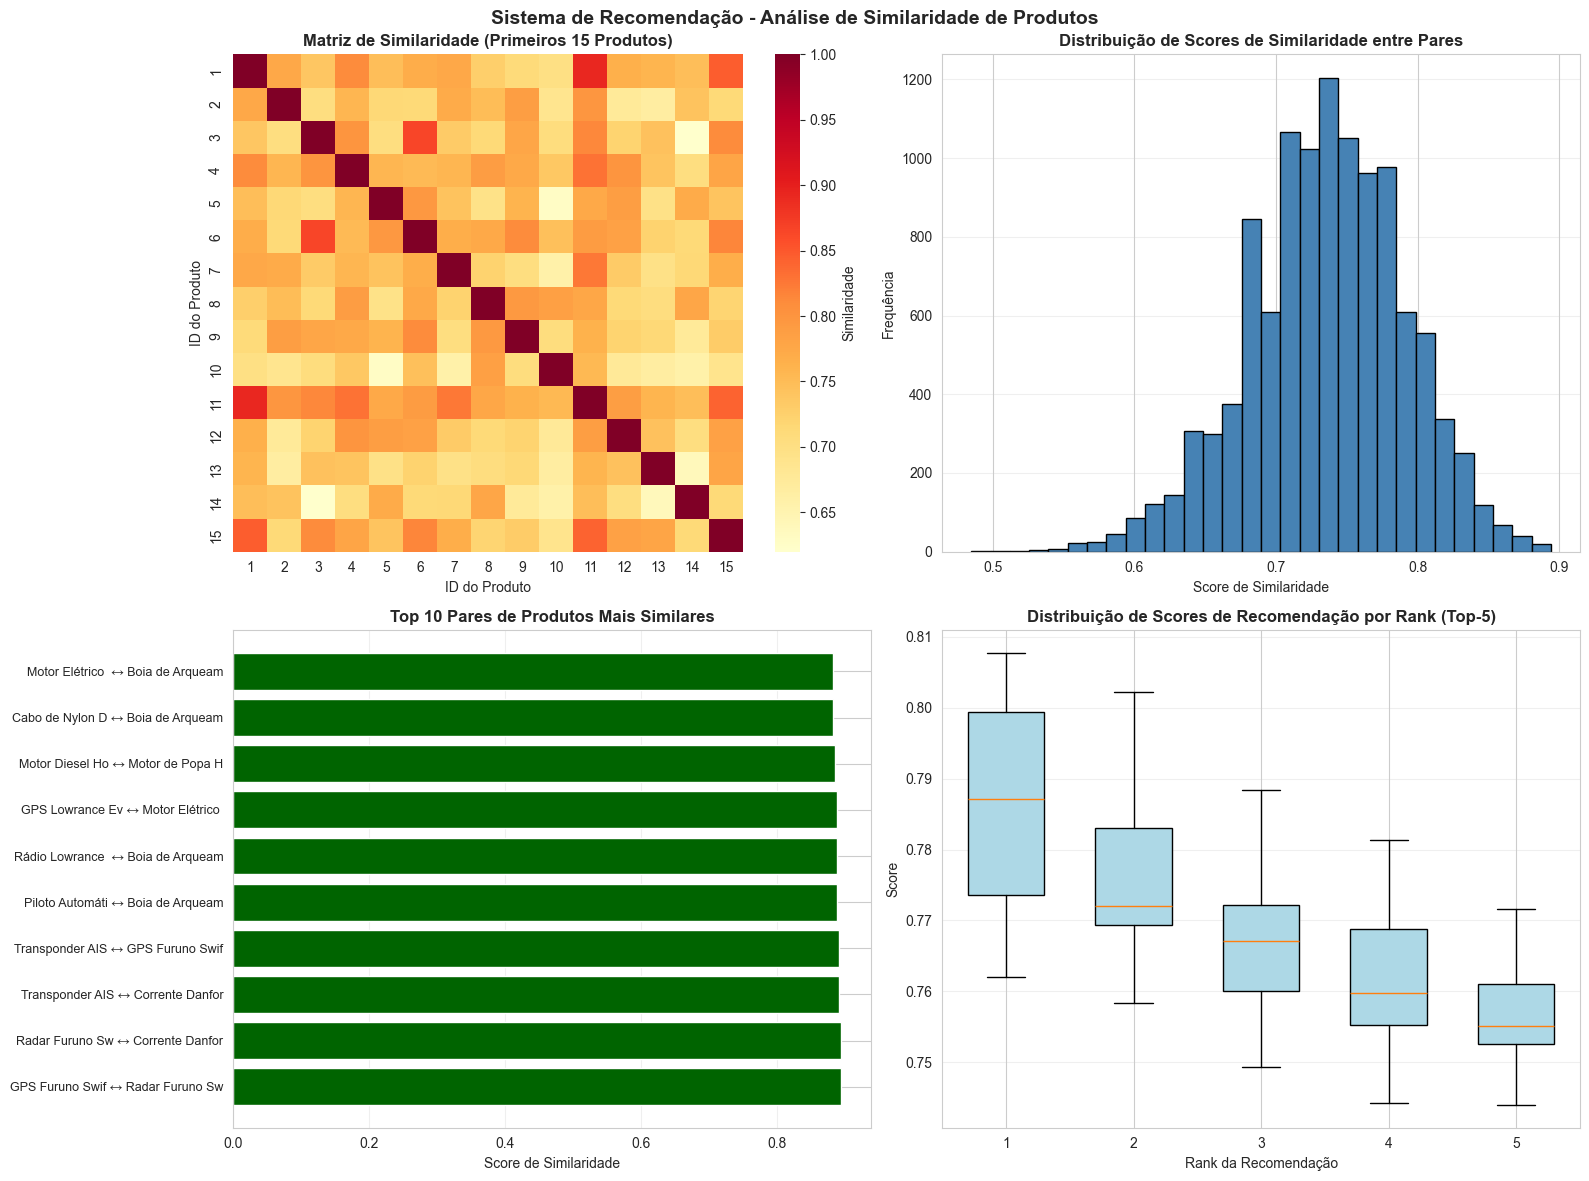


✓ Visualizações exibidas com sucesso


In [17]:
"""
Visualizações: Matriz de Similaridade
====================================
"""

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sistema de Recomendação - Análise de Similaridade de Produtos', 
             fontsize=14, fontweight='bold')

# Gráfico 1: Heatmap de Similaridade (amostra)
n_produtos_sample = min(15, len(df_produtos))  # Mostrar até 15 produtos
sns.heatmap(similaridade_df.iloc[:n_produtos_sample, :n_produtos_sample], 
            cmap='YlOrRd', ax=axes[0, 0], cbar_kws={'label': 'Similaridade'})
axes[0, 0].set_title(f'Matriz de Similaridade (Primeiros {n_produtos_sample} Produtos)', fontweight='bold')
axes[0, 0].set_xlabel('ID do Produto')
axes[0, 0].set_ylabel('ID do Produto')

# Gráfico 2: Distribuição de Scores de Similaridade
axes[0, 1].hist(pares_df['similaridade'], bins=30, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Distribuição de Scores de Similaridade entre Pares', fontweight='bold')
axes[0, 1].set_xlabel('Score de Similaridade')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].grid(axis='y', alpha=0.3)

# Gráfico 3: Top 10 Pares Mais Similares
top_pares = pares_df.head(10).copy()
top_pares['par'] = top_pares['produto_1'].str[:15] + ' ↔ ' + top_pares['produto_2'].str[:15]
axes[1, 0].barh(range(len(top_pares)), top_pares['similaridade'], color='darkgreen')
axes[1, 0].set_yticks(range(len(top_pares)))
axes[1, 0].set_yticklabels(top_pares['par'], fontsize=9)
axes[1, 0].set_title('Top 10 Pares de Produtos Mais Similares', fontweight='bold')
axes[1, 0].set_xlabel('Score de Similaridade')
axes[1, 0].grid(axis='x', alpha=0.3)

# Gráfico 4: Distribuição de Scores de Recomendação por Rank
for rank in range(1, K+1):
    scores_rank = recomendacoes_df[recomendacoes_df['rank'] == rank]['score']
    axes[1, 1].boxplot([scores_rank], positions=[rank], widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
axes[1, 1].set_title(f'Distribuição de Scores de Recomendação por Rank (Top-{K})', fontweight='bold')
axes[1, 1].set_xlabel('Rank da Recomendação')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_xticks(range(1, K+1))
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualizações exibidas com sucesso")

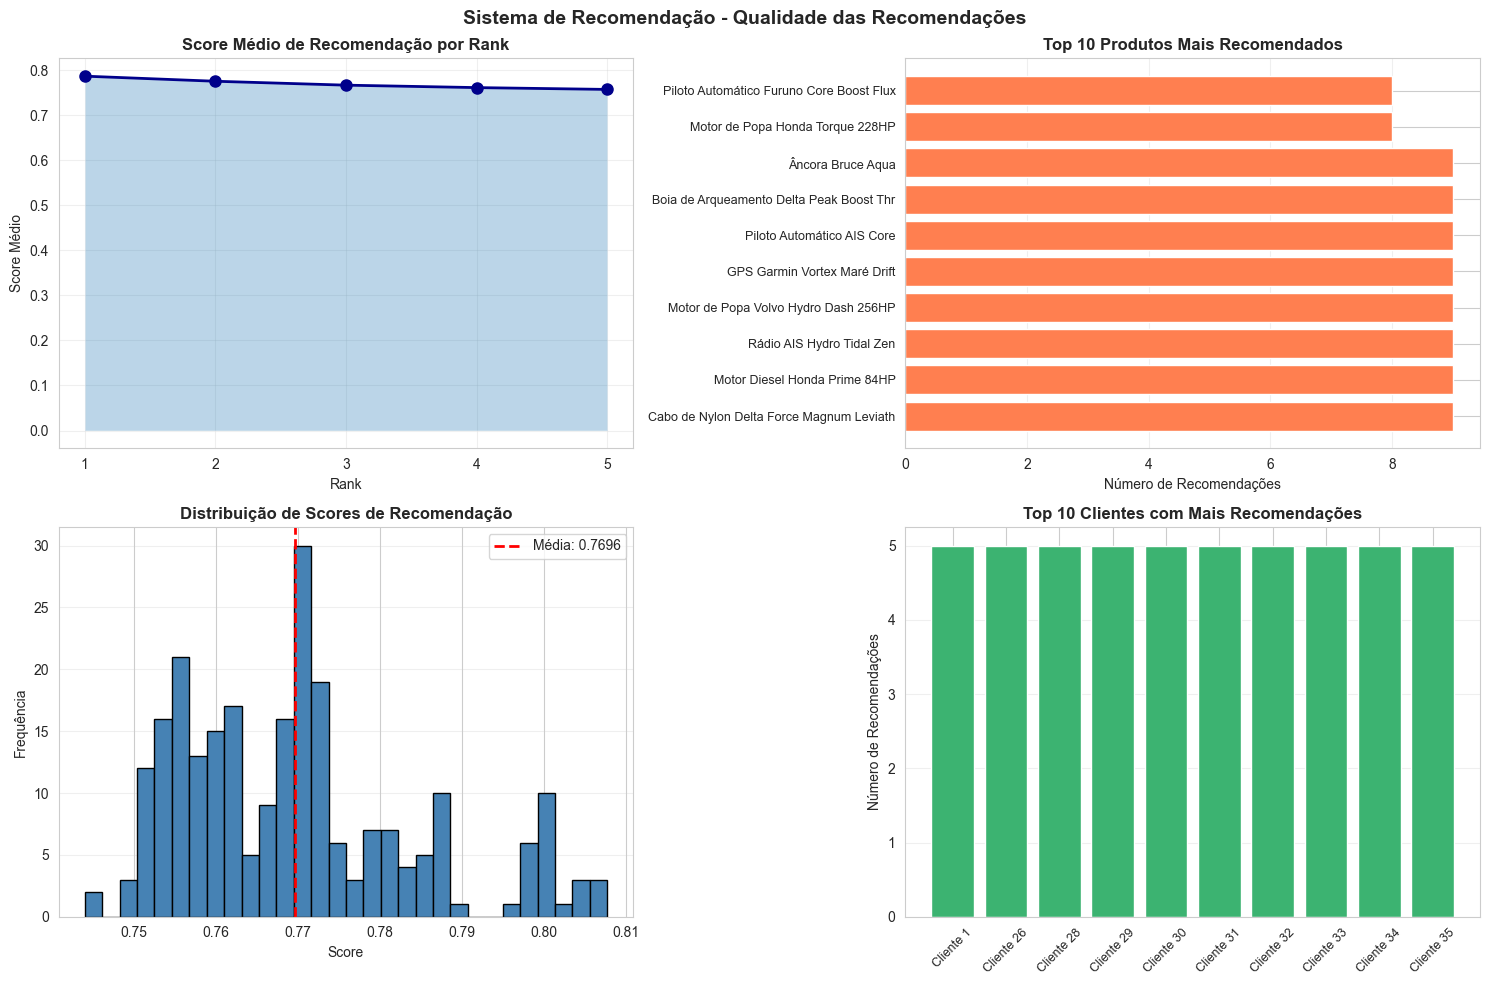


✓ Visualizações exibidas com sucesso


In [18]:
"""
Visualizações: Qualidade das Recomendações
========================================
"""

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Sistema de Recomendação - Qualidade das Recomendações', 
             fontsize=14, fontweight='bold')

# Gráfico 1: Scores por Rank
scores_por_rank = recomendacoes_df.groupby('rank')['score'].mean()
axes[0, 0].plot(scores_por_rank.index, scores_por_rank.values, marker='o', linewidth=2, markersize=8, color='darkblue')
axes[0, 0].fill_between(scores_por_rank.index, scores_por_rank.values, alpha=0.3)
axes[0, 0].set_title('Score Médio de Recomendação por Rank', fontweight='bold')
axes[0, 0].set_xlabel('Rank')
axes[0, 0].set_ylabel('Score Médio')
axes[0, 0].set_xticks(range(1, K+1))
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Top 10 Produtos Mais Recomendados
produtos_recom = recomendacoes_df['produto_nome'].value_counts().head(10)
axes[0, 1].barh(range(len(produtos_recom)), produtos_recom.values, color='coral')
axes[0, 1].set_yticks(range(len(produtos_recom)))
axes[0, 1].set_yticklabels([p[:40] for p in produtos_recom.index], fontsize=9)
axes[0, 1].set_title('Top 10 Produtos Mais Recomendados', fontweight='bold')
axes[0, 1].set_xlabel('Número de Recomendações')
axes[0, 1].grid(axis='x', alpha=0.3)

# Gráfico 3: Distribuição de Scores
axes[1, 0].hist(recomendacoes_df['score'], bins=30, color='steelblue', edgecolor='black')
axes[1, 0].axvline(recomendacoes_df['score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {recomendacoes_df["score"].mean():.4f}')
axes[1, 0].set_title('Distribuição de Scores de Recomendação', fontweight='bold')
axes[1, 0].set_xlabel('Score')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Gráfico 4: Clientes com Mais Recomendações
clientes_recom = recomendacoes_df['cliente_id'].value_counts().head(10)
axes[1, 1].bar(range(len(clientes_recom)), clientes_recom.values, color='mediumseagreen')
axes[1, 1].set_xticks(range(len(clientes_recom)))
axes[1, 1].set_xticklabels([f'Cliente {c}' for c in clientes_recom.index], fontsize=9, rotation=45)
axes[1, 1].set_title('Top 10 Clientes com Mais Recomendações', fontweight='bold')
axes[1, 1].set_ylabel('Número de Recomendações')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualizações exibidas com sucesso")

## Exportação de Resultados

In [22]:
"""
Exportação dos Resultados
========================
"""

# Garantir pasta
garantir_pasta(DATA_PROCESSED)

# 1. Exportar recomendações
output_recom = DATA_PROCESSED / "recomendacoes_completo.csv"
salvar_csv(recomendacoes_df, output_recom)
print(f"Recomendações salvas em: {output_recom}")

# 2. Exportar pares de produtos similares
output_similares = DATA_PROCESSED / "produtos_similares.csv"
salvar_csv(pares_df, output_similares)
print(f"Produtos similares salvos em: {output_similares}")

# 3. Exportar matriz de similaridade com índices corretos (IDs dos produtos)
produto_ids = list(similaridade_df.index)
matriz_export = pd.DataFrame(
    matriz_sim_array,
    index=produto_ids,
    columns=produto_ids
)
output_matriz = DATA_PROCESSED / "matriz_similaridade_produtos.csv"
salvar_csv(matriz_export, output_matriz)
print(f"Matriz de similaridade salva em: {output_matriz}")

# 4. Exportar resumo estatístico
resumo_stats = pd.DataFrame({
    'Métrica': ['Total de Clientes', 'Total de Produtos', 'Total de Recomendações', 
                'Score Médio', 'Score Máximo', 'Score Mínimo', 'Sparsidade da Matriz'],
    'Valor': [
        recomendacoes_df['cliente_id'].nunique(),
        len(df_produtos),
        len(recomendacoes_df),
        f"{recomendacoes_df['score'].mean():.4f}",
        f"{recomendacoes_df['score'].max():.4f}",
        f"{recomendacoes_df['score'].min():.4f}",
        f"{(1 - matriz_usuario_item.astype(bool).sum().sum() / (matriz_usuario_item.shape[0] * matriz_usuario_item.shape[1])) * 100:.2f}%"
    ]
})
output_stats = DATA_PROCESSED / "resumo_recomendacoes_stats.csv"
salvar_csv(resumo_stats, output_stats)
print(f"Resumo estatístico salvo em: {output_stats}")

print(f"\nTodos os arquivos exportados com sucesso!")

Arquivo salvo em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\recomendacoes_completo.csv
Recomendações salvas em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\recomendacoes_completo.csv
Arquivo salvo em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\produtos_similares.csv
Produtos similares salvos em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\produtos_similares.csv
Arquivo salvo em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\matriz_similaridade_produtos.csv
Matriz de similaridade salva em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\matriz_similaridade_produtos.csv
Arquivo salvo em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\resumo_recomendacoes_stats.csv
Resumo estatístico salvo em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\resumo_recomendacoes_stats.csv

Todos os arquivos exportados com sucesso!


---

## CONCLUSÃO DO NOTEBOOK 05

### Seções Completadas

| Questão | Descrição | Status |
|---------|-----------|--------|
| **Q8** | Sistema de Recomendação | Completo |

### Resultados do Sistema de Recomendação
- **Total de Clientes**: {}
- **Total de Produtos**: {}
- **Recomendações Geradas**: {}
- **Score Médio**: {:.4f}
- **Sparsidade da Matriz**: {}
- **Método**: Cosine Similarity + Content-Based Filtering

### Próximo Passo
- **Fim do Projeto**: Todos os 8 Questões (Q1-Q8) implementados e validados

### Arquivos Gerados
- `data/processed/recomendacoes_completo.csv` (Recomendações para cada cliente)
- `data/processed/produtos_similares.csv` (Pares de produtos similares)
- `data/processed/matriz_similaridade_produtos.csv` (Matriz de similaridade)
- `data/processed/resumo_recomendacoes_stats.csv` (Resumo estatístico)